# Discrete-event experiments — analysis & visualisation

This notebook reads the **archived simulation data** written by `discrete_events.py`
and reproduces everything that used to be baked into the run script:

* **divisions** / **deaths** (flat square) — a colour-coded 2-D **GIF** (faces by
  cell state: grey `normal`, plus that scenario's own event state — magenta
  `dividing` for divisions, black `extruding` for deaths). Animations only: the
  events are what these two scenarios are about, so no stills are written.
* **gillespie** and **gillespie_restart** (3-D crypt) — for each run, the cell-type
  colour-coded 3-D **GIF** + stills, and two analyses: cell-type distribution over
  time, and one **combined along-z figure** stacking the cell-type spatial
  distribution over the event-type (division / differentiation / extrusion)
  distribution on a shared crypt axis. The two runs are the same model with the
  same parameters and the same solver step, differing only in their starting
  tissue — `gillespie` starts from the stock crypt mesh, `gillespie_restart` from
  the settled tissue `gillespie` ends on — so a final figure puts their cell-type
  trajectories side by side.

Each scenario's `outputs/<scenario>/history.hf5` is reopened with
`HistoryHdf5.from_archive`; the crypt **events** (which come from the process
emitter, not the History) are read from `outputs/<scenario>/events.csv`. Re-analyse
without re-simulating, and re-run `discrete_events.py` without disturbing earlier
analysis.

Run from the repo's **`vivarium-tyssue` conda env** (needs ImageMagick `magick`
on PATH for the GIFs).


## The simulations

All four runs put **discrete stochastic cell events on top of a continuous
vertex-model mechanics**. The mechanics is the same everywhere; only the process
that decides *when* and *to whom* an event happens differs — and, for the two
crypt runs, the tissue they start from.

### Mechanics — vertex model

Cells are polygons $\alpha$ of area $A_\alpha$ and perimeter $P_\alpha$; junctions
$\langle ij\rangle$ have length $\ell_{ij}$ and line tension $\Lambda_{ij}$:

$$
E \;=\; \sum_{\alpha}\left[\frac{K_A}{2}\left(A_\alpha - A_{0,\alpha}\right)^2
      \;+\; \frac{K_P}{2}\left(P_\alpha - P_0\right)^2\right]
  \;+\; \frac{1}{2}\sum_{\langle ij\rangle} \Lambda_{ij}\,\ell_{ij},
\qquad
\eta \,\frac{\mathrm{d}\mathbf{r}_i}{\mathrm{d}t} = -\frac{\partial E}{\partial \mathbf{r}_i},
$$

integrated by forward Euler with step $\Delta t$. Note that the **preferred area
$A_{0,\alpha}$ is per cell** — that is the handle every discrete event pulls on.

### How an event is executed

Events are never instantaneous topology flips: a cell committed to an event has
its preferred area ramped each solver step until its *actual* area crosses a
threshold:

$$
\textbf{division:}\quad A_{0}(t+\Delta t) = A_{0}(t)\,\bigl(1 + g\,\Delta t\bigr),
\quad\text{split when } A > A_c^{\mathrm{div}} ,
$$

$$
\textbf{extrusion:}\quad A_{0}(t+\Delta t) = A_{0}(t)\,\bigl(1 - s\,\Delta t\bigr),
\quad\text{remove when } A < A_c^{\mathrm{ex}} \;\text{ or }\; A_0 < A_{\min} ,
$$

with growth rate $g$, shrink rate $s$ and a **death floor** $A_{\min}$ on the
shrinking target $A_0$. The floor exists for the crypt: its top rim stays
mechanically stretched, so without the $A_0$ criterion a committed cell there would
never reach $A_c^{\mathrm{ex}}$. It is set **per commitment**
(`behaviors.DEATH_FLOOR` = 0.5 by default, which the crypt uses).

On the relaxed flat square the floor has the opposite effect: it fires while a dying
cell is still near full size — measured at $A \approx 0.83$ — so $A_c^{\mathrm{ex}}$
never governed at all. The deaths scenario therefore sets $A_{\min}$ = `DEATH_FLOOR`
= 0.01, far **below** $A_c^{\mathrm{ex}}$, handing the decision back to the area
threshold.

That alone is not enough: a cell holding its full preferred perimeter cannot be
squeezed arbitrarily small, because the perimeter term resists it. With $P_0 = 3.6$
held fixed, a dying cell's area plateaus near $A \approx 0.35$ however far $A_0$
falls — it simply stops shrinking and is never removed. So the deaths scenario also
constricts the dying cell's **target perimeter** at the same rate
(`DEATH_CONTRACT`, i.e. `contract_perimeter` on `CellDeaths`),

$$
\textbf{apoptotic constriction:}\quad
P_{0}(t+\Delta t) = P_{0}(t)\,\bigl(1 - s\,\Delta t\bigr),
$$

which lets the cell collapse all the way to $A_c^{\mathrm{ex}}$. Measured over the
run: 10 of 13 removals fire at $A$ = 0.200–0.203, i.e. exactly at the threshold; the
other 3 are caught by the floor at $A \approx 0.25$ — locally crowded cells that
could not quite reach it, which without the floor would shrink forever. Both the
floor and the constriction are per-commitment settings, so the crypt keeps the
default behaviour ($A_{\min} = 0.5$, no constriction) that its stretched top rim
needs.

### Scenarios 1 & 2 — Poisson divisions / deaths (flat square)

`CellDivisions` and `CellDeaths` are homogeneous Poisson processes: in each solver
step of length $\Delta t$ the number of events is

$$
n \;\sim\; \mathrm{Poisson}\!\left(k\,\Delta t\right),
\qquad
P(n \text{ events}) = \frac{(k\Delta t)^n e^{-k\Delta t}}{n!},
$$

capped at the number of eligible cells, and the $n$ cells are drawn uniformly at
random from those not already mid-event. $k$ is `DIV_RATE` / `DEATH_RATE`.

### Scenario 3 — Gillespie crypt (3-D)

The crypt carries cell types (`sc` stem, `pc` progenitor, `ent` enterocyte,
`gc` goblet) and a set of transitions $j$ per type — self-renewal (division),
differentiation into another type, and extrusion `ex`. Each transition has a
maximum rate $R^{\max}_{c,j}$, and the actual rate of a cell is modulated by local
regulators:

$$
R_{c,j}(\mathrm{cell}) \;=\; R^{\max}_{c,j}\;
  \prod_{\text{positive } q} \Phi\bigl(x_q; K_q, w_q\bigr)\;
  \prod_{\text{negative } q} \bigl[1 - \Phi\bigl(x_q; K_q, w_q\bigr)\bigr].
$$

The regulators $x_q$ are the **Wnt signal**, proxied by the cell's position along
the crypt axis $x_{\mathrm{wnt}} = z$ (high at the crypt base), and the local
**density** $x_{\mathrm{dens}} = 1/A$. $\Phi$ is a smooth cubic switch (a
smoothstep) rising from $0$ to $1$ across a window of half-width $w$ centred on
$K$:

$$
\Phi(x; K, w) =
\begin{cases}
0, & x < K-w,\\
\dfrac{1}{2} + \dfrac{3}{4}u - \dfrac{1}{4}u^{3},\quad u = \dfrac{x-K}{w}, & |u| \le 1,\\
1, & x > K+w,
\end{cases}
$$

so $K$ sets *where* a regulator switches a transition on and $w$ *how sharply*.

Events are drawn with a **rejection (Gillespie / thinning) scheme** on the
upper-bound rates. The waiting time to the next event uses the total maximum rate
$R^{\max}_{\mathrm{tot}} = \sum_{\mathrm{cells}} \sum_j R^{\max}_{c,j}$:

$$
\Delta t_{\mathrm{next}} \;=\; -\,\frac{\ln u_0}{R^{\max}_{\mathrm{tot}}},
\qquad u_0 \sim \mathcal{U}(0,1),
$$

a cell is picked with probability $\propto \sum_j R^{\max}_{c,j}$, one of its
transitions $j$ with probability $\propto R^{\max}_{c,j}$, and the candidate event
is **accepted** only if

$$
\frac{R_{c,j}(\mathrm{cell})}{R^{\max}_{c,j}} \;\ge\; u_1,
\qquad u_1 \sim \mathcal{U}(0,1),
$$

otherwise it is rejected and the next draw is taken. This reproduces the exact
statistics of the space- and state-dependent rates $R_{c,j}$ without recomputing
every cell's rate at every step.

Note that $\Delta t_{\mathrm{next}}$ is the process's **own** clock, drawn from the
rates: `Gillespie.calculate_timestep` returns it and `process_bigraph` schedules the
next update there, so the event statistics are set by $R^{\max}$ alone and are
*independent of the solver step* $\Delta t$. The crypt runs at $\Delta t = 0.001$
rather than the earlier $0.005$ purely for the mechanics: an explicit-Euler
displacement is linear in $\Delta t$, and at $0.005$ the transient gradient
following a division or extrusion could push a single vertex off the tube in one
step and let neighbouring faces overlap. The one quantity that must follow the
solver step is the growth / shrink increment $g\,\Delta t$ of a committed cell,
whose ramp is applied once per solver step — the `Gillespie`'s `global_interval`
carries it, so a cell's growth per unit time is unchanged.

### Scenario 4 — the same crypt, restarted from a settled tissue

`gillespie_restart` re-runs scenario 3 unchanged, but starting from the mesh
scenario 3 *ends* on rather than from the stock `crypt_cylinder.hf5`. The stock
mesh's cell types come from a spatial prior, not from the dynamics, so scenario 3
spends much of its window relaxing into the crypt's stationary composition; the
restart begins at that composition. Any commitment still pending at the checkpoint
(a cell mid-growth toward division, or mid-shrink toward extrusion) is settled
before the mesh is written, since the queue driving it lives on the solver's event
manager and cannot cross runs.

### Parameters

| symbol | meaning | code / value |
|---|---|---|
| $K_A,\;A_0$ | area elasticity, preferred area | `area_elasticity`, `prefered_area` |
| $K_P,\;P_0$ | perimeter elasticity, preferred perimeter | `perimeter_elasticity`, `prefered_perimeter` |
| $\eta$ | vertex friction | `viscosity` |
| $k$ | Poisson event rate | `DIV_RATE` = `DEATH_RATE` = 0.4 |
| $g,\;A_c^{\mathrm{div}}$ | growth rate, division area | `DIV_GROWTH` = 0.3, `DIV_CRIT` = 2.0 |
| $s,\;A_c^{\mathrm{ex}}$ | shrink rate, extrusion area | `DEATH_SHRINK` = 0.3, `DEATH_CRIT` = 0.2 |
| $A_{\min}$ | death floor on $A_0$ | `DEATH_FLOOR` = 0.05 here; 0.5 (the `behaviors` default) in the crypt |
| $R^{\max}_{c,j}$ | maximum transition rates | `rates_max` (`jump_rates.py`) |
| $K_q,\;w_q$ | regulation midpoint, transition half-width | `K`, `k` (`jump_rates.py`) |
| $z$ | crypt axis = Wnt coordinate | `regulation_loc["wnt"] = "z"` |
| $\Delta t,\;T$ | solver step, total time | flat 0.05 / 50; crypt 0.001 / 72 |

In [1]:
from __future__ import annotations
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# Simulation config is the single source of truth — import it from the sim script.
import discrete_events as sim
from discrete_events import OUT_DIR, COORDS_2D, COORDS_3D

sys.path.insert(0, str(sim.REPO))   # so vivarium_tyssue.draw / tyssue import cleanly
from tyssue.core.history import HistoryHdf5

# --- visualisation / analysis constants (were in the old monolithic script) ---
FIG_DPI = 300          # publication-quality raster resolution for stills / plots
GIF_DPI = 120          # animations (kept lower — many frames)
NUM_GIF_FRAMES = 120
N_STILLS = 5

# Flat-sheet cell "states": neutral background + the two event highlights.
FLAT_TYPE_COLORS = {"normal": "#CFCFCF", "dividing": "#C71FE0", "extruding": "#000000"}

Z_NBINS = 12       # event-type histogram along z
Z_NBINS_CT = 48    # finer bins for the cell-type-along-z line plot

BIO_TYPES = ["sc", "pc", "ent", "gc"]                       # true crypt cell types
CELL_TYPE_ORDER = BIO_TYPES + ["dividing", "extruding"]     # + transient states

print("archives:", OUT_DIR)

archives: /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/discrete_events/outputs


## The composite bigraph

Each scenario is a `process_bigraph` **composite**: the `EulerSolver` process
(`Tyssue`) integrating the vertex model, plus the discrete-event process that drives
it (`Divisions`, `Deaths` or `Gillespie`), wired to shared **stores** — `Tissue State`
(the tyssue `vert` / `edge` / `face` / `cell` dataframes), `Behaviors` (the queue of
pending cell events), `global_time`, `Network Changed` and — for gillespie — the
`Gillespie Trigger`. The event processes never touch the mesh directly: they read
`Tissue State` and push behaviours, and the solver executes them.

`bigraph_viz` draws the wiring below in the style of `Notebooks/simulation_walkthrough.ipynb`, with the manuscript palette:
**processes are boxes in peach / pink**, **stores are circles in light blue**
(defined once in `Experiments/bigraph_style.py`). Every spec comes straight
from the simulation script, so the diagram cannot drift from what was run;
the PNGs are written to `outputs/bigraphs/`.

In [2]:
from IPython.display import display

sys.path.insert(0, str(sim.REPO / "Experiments"))   # shared bigraph palette
from bigraph_style import plot_experiment_bigraph
from vivarium_tyssue.core import build_core
from process_bigraph.emitter import emitter_from_wires

core = build_core()                    # the same core the simulation runs on
BIGRAPH_DIR = OUT_DIR / "bigraphs"

flat = sim.ensure_dataset(sim.FLAT_DATASET)
crypt = sim.ensure_dataset(sim.CRYPT_DATASET)

gillespie_spec = sim.build_gillespie_spec(crypt)
# The gillespie run adds this emitter — it is what `events.csv` is collected from.
gillespie_spec["emitter"] = emitter_from_wires({
    "global_time": ["global_time"],
    "behaviors": ["Behaviors"],
})

for name, spec in [
    ("divisions", sim.build_divisions_spec(flat)),
    ("deaths", sim.build_deaths_spec(flat)),
    ("gillespie", gillespie_spec),
]:
    display(plot_experiment_bigraph(
        spec, core=core, filename=f"{name}_bigraph", out_dir=BIGRAPH_DIR))

skipping `process_bigraph.server.rest` (missing optional dep `fastapi_utils`)
module `pbg_emitters.xarray_emitter` not found during dynamic import


wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/discrete_events/outputs/bigraphs/divisions_bigraph.png


wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/discrete_events/outputs/bigraphs/deaths_bigraph.png


wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/discrete_events/outputs/bigraphs/gillespie_bigraph.png


## Loading an archived history

Same helper as the other experiment notebooks: reopen the archive with
`HistoryHdf5.from_archive` for drawing, read the full stacked dataframes from the
HDF5 store for analysis, and rebuild each retrieved frame from those stacked tables
(restoring the per-frame topological index from the `vert` / `edge` / `face`
columns) so drawing and geometry updates line up.

In [3]:
class LoadedHistory:
    # Reopened archive with the same surface as an in-memory tyssue History:
    # .time_stamps, .retrieve(t) (drawing), .datasets (full stacked dfs, analysis).
    def __init__(self, path):
        self._h = HistoryHdf5.from_archive(str(path))
        self._sheet = self._h.sheet
        with pd.HDFStore(str(path), "r") as store:
            self.datasets = {k.strip("/"): store.select(k) for k in store.keys()}
        self._times = np.array(sorted(self.datasets["vert"]["time"].unique()))

    @property
    def time_stamps(self):
        return self._times

    def retrieve(self, t):
        # Rebuild a sheet at the nearest recorded time from the stacked datasets,
        # restoring each element's per-frame index from its vert/edge/face column.
        t = self._times[int(np.argmin(np.abs(self._times - t)))]
        sheet_datasets = {}
        for elem, df in self.datasets.items():
            sub = df[df["time"] == t]
            if elem in sub.columns:
                sub = sub.set_index(elem)
                sub.index.name = elem
            sheet_datasets[elem] = sub
        sheet = type(self._sheet)(f"{self._sheet.identifier}_{t:04.3f}",
                                  sheet_datasets, self._sheet.specs)
        sheet.coords = self._sheet.coords
        return sheet

    def update_datasets(self):
        pass

    def __getattr__(self, name):
        return getattr(self._h, name)


def load_events(path) -> list:
    # gillespie events.csv -> list of {time, func, cell_uid} dicts.
    path = Path(path)
    if not path.exists():
        return []
    df = pd.read_csv(path)
    if "cell_uid" in df.columns:
        df["cell_uid"] = pd.to_numeric(df["cell_uid"], errors="coerce")
    return df.to_dict("records")

## Drawing — 2-D flat sheet (divisions / deaths), faces by cell state

The legend lists only the states the scenario can produce, so the deaths animation
never advertises a `dividing` colour (or the divisions animation an `extruding` one).

In [4]:
def _flat_face_color(sheet):
    # (Nf, 4) RGBA: normal grey, dividing magenta, dying/extruding black.
    return np.array([
        mcolors.to_rgba(FLAT_TYPE_COLORS.get(ct, FLAT_TYPE_COLORS["normal"]))
        for ct in sheet.face_df["cell_type"]
    ])


# Each flat-sheet scenario only ever produces its own event state, so the legend is
# built from the states that scenario can actually show (a "dividing" key on the
# deaths gif — or "extruding" on the divisions gif — is just noise).
FLAT_STATES = {"divisions": ("normal", "dividing"), "deaths": ("normal", "extruding")}


def _flat_legend_handles(states):
    return [Patch(facecolor=FLAT_TYPE_COLORS[k], edgecolor="#808080", label=k)
            for k in states]


def _frame_limits(history, times, coords):
    # Fixed (min, max) per-axis limits from the first frame, with a 5% margin.
    sheet0 = history.retrieve(times[0])
    bounds = sheet0.vert_df[coords].describe().loc[["min", "max"]]
    margin = (bounds.loc["max"] - bounds.loc["min"]).max() * 0.05
    return {c: (bounds.loc["min", c] - margin, bounds.loc["max", c] + margin) for c in coords}


def _draw_2d_frame(sheet, title, lims, states):
    # Draw one flat-sheet frame (faces by cell state). Returns Figure or None.
    from tyssue.draw import sheet_view
    try:
        fig, ax = plt.subplots(figsize=(6.4, 5.0))
        sheet_view(
            sheet, coords=COORDS_2D, ax=ax,
            face={"visible": True, "color": _flat_face_color(sheet), "alpha": 1.0},
            edge={"visible": True, "color": "#808080", "width": 1.0},
        )
        ax.set_aspect("equal")
        ax.set_xlim(*lims["x"]); ax.set_ylim(*lims["y"])
        ax.set_title(title, fontsize=10)
        ax.legend(handles=_flat_legend_handles(states), loc="upper left",
                  bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=8)
    except Exception as exc:  # noqa: BLE001
        print(f"frame {title} failed ({type(exc).__name__}: {exc}); skipping")
        plt.close("all")
        return None
    return fig


def save_gif_2d(history, out_path: Path, states):
    times = list(history.time_stamps)
    if not times:
        return
    lims = _frame_limits(history, times, COORDS_2D)
    idx = np.unique(np.round(np.linspace(0, len(times) - 1,
                                         min(NUM_GIF_FRAMES, len(times)))).astype(int))
    tmp = Path(tempfile.mkdtemp())
    n = 0
    try:
        for i in idx:
            t = times[int(i)]
            fig = _draw_2d_frame(history.retrieve(t), f"t = {float(t):.1f}", lims, states)
            if fig is None:
                continue
            fig.savefig(tmp / f"frame_{n:04d}.png", dpi=GIF_DPI, bbox_inches="tight")
            plt.close(fig); n += 1
        if n == 0:
            print(f"no renderable frames for {out_path.name}; skipping GIF"); return
        subprocess.run(["magick", "-delay", "12", "-loop", "0",
                        (tmp / "frame_*.png").as_posix(), str(out_path)], check=True)
        print(f"  wrote {out_path.name} ({n} frames)")
    finally:
        shutil.rmtree(tmp, ignore_errors=True)


## Drawing — 3-D crypt (gillespie), faces by cell_type

Every frame is rendered ourselves (rather than via `tyssue.create_gif_3d`) because
that helper calls `savefig` outside its per-frame try/except, so a single frame
whose matplotlib-3D projection goes singular (which happens on the crypt after a
division/extrusion reindexes the mesh) aborts the whole GIF. Here each frame is
guarded, so a bad frame is skipped and the rest of the animation survives.

In [5]:
def _draw_3d_frame(sheet, lims, title, figsize=None):
    # Draw one crypt frame (faces by cell_type) into a fresh Axes3D. Returns Figure or None.
    from tyssue import config
    from tyssue.draw.plt_draw import (
        sheet_view_3d, patch_2d_collections_to_3d, _auto_tick_fontsize_3d,
    )
    from vivarium_tyssue.draw import crypt_cell_type_kwds, CELL_TYPE_COLORS

    ds = config.draw.sheet_spec()
    ds["face"]["visible"] = True
    ds["face"]["alpha"] = 1.0
    # Grey (not black) edges so the black "extruding" faces stay distinguishable.
    ds["edge"]["color"] = "#808080"
    ds["face"]["color"] = crypt_cell_type_kwds(sheet)["face"]["color"]
    try:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection="3d")
        ax.view_init(elev=30, azim=45)
        fig, ax = sheet_view_3d(
            sheet, coords=COORDS_3D, ax=ax,
            legend=CELL_TYPE_COLORS, cull_back_edges=True, **ds,
        )
        patch_2d_collections_to_3d(ax)
        ax.set(xlim=lims["x"], ylim=lims["y"], zlim=lims["z"])
        # Recompute the box aspect from the FIXED limits (sheet_view_3d set it from
        # this frame's auto-scaled extent), else the crypt's long z-axis drifts frame
        # to frame as divisions/extrusions shift the per-frame z-extent.
        ax.set_box_aspect((lims["x"][1] - lims["x"][0],
                           lims["y"][1] - lims["y"][0],
                           lims["z"][1] - lims["z"][0]))
        # Same reason for the tick-label font (sheet_view_3d sized it per-frame).
        _auto_tick_fontsize_3d(ax, base_size=8, min_size=4)
        ax.set_title(title, fontsize=9)
        # Force the (occasionally singular) projection now, inside the guard.
        fig.canvas.draw()
    except Exception as exc:  # noqa: BLE001
        print(f"frame {title} failed ({type(exc).__name__}: {exc}); skipping")
        plt.close("all")
        return None
    return fig


def save_gif_3d(history, out_path: Path):
    times = list(history.time_stamps)
    if not times:
        return
    lims = _frame_limits(history, times, COORDS_3D)
    idx = np.unique(np.round(np.linspace(0, len(times) - 1,
                                         min(NUM_GIF_FRAMES, len(times)))).astype(int))
    tmp = Path(tempfile.mkdtemp())
    n = 0
    try:
        for i in idx:
            t = times[int(i)]
            fig = _draw_3d_frame(history.retrieve(t), lims, f"t = {float(t):.2f}", figsize=(5.0, 8.0))
            if fig is None:
                continue
            fig.savefig(tmp / f"frame_{n:04d}.png", dpi=GIF_DPI)
            plt.close(fig); n += 1
        if n == 0:
            print(f"no renderable frames for {out_path.name}; skipping GIF"); return
        subprocess.run(["magick", "-delay", "12", "-loop", "0",
                        (tmp / "frame_*.png").as_posix(), str(out_path)], check=True)
        print(f"  wrote {out_path.name} ({n} frames)")
    finally:
        shutil.rmtree(tmp, ignore_errors=True)


def save_stills_3d(history, out_dir: Path):
    times = list(history.time_stamps)
    if not times:
        return
    lims = _frame_limits(history, times, COORDS_3D)
    for frac in np.linspace(0.0, 1.0, N_STILLS):
        t = times[int(round(frac * (len(times) - 1)))]
        # Fixed figsize (as the gif) and NO bbox_inches="tight": tight-cropping would
        # resize each still to its own content, so the crypt's z-axis would look a
        # different length per snapshot. Constant figsize + box_aspect keep it stable.
        fig = _draw_3d_frame(history.retrieve(t), lims, f"t = {float(t):.2f}", figsize=(5.0, 8.0))
        if fig is None:
            continue
        fig.savefig(out_dir / f"still_t{float(t):06.2f}.png", dpi=FIG_DPI)
        plt.close(fig)

## Analysis (gillespie)

In [6]:
def _type_palette():
    from vivarium_tyssue.draw import CELL_TYPE_COLORS
    return CELL_TYPE_COLORS


def cell_type_over_time(history) -> pd.DataFrame:
    # Count of each cell type at every recorded timepoint (wide: time x types).
    face = history.datasets["face"]
    df = face[face["is_alive"] > 0] if "is_alive" in face.columns else face
    counts = df.groupby(["time", "cell_type"]).size().unstack(fill_value=0)
    counts = counts.reindex(sorted(counts.index)).reset_index()
    return counts


def cell_type_along_z(history, nbins: int = Z_NBINS_CT) -> pd.DataFrame:
    # Mean count of each cell type per z-bin, averaged over all timepoints.
    face = history.datasets["face"]
    df = (face[face["is_alive"] > 0] if "is_alive" in face.columns else face).copy()
    z = df["z"].astype(float)
    bins = np.linspace(z.min(), z.max(), nbins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    df["zbin"] = pd.cut(z, bins, include_lowest=True, labels=centers)
    n_frames = df["time"].nunique()
    g = df.groupby(["zbin", "cell_type"], observed=True).size().reset_index(name="count")
    g["count"] = g["count"] / max(n_frames, 1)          # per-frame mean occupancy
    g["zcenter"] = g["zbin"].astype(float)
    return g[["zcenter", "cell_type", "count"]]


def events_along_z(history, events: list, nbins: int = Z_NBINS) -> pd.DataFrame:
    # Count of each event type per z-bin. Each event's z is the mean z of its cell
    # (by unique_id) across the recorded history.
    face = history.datasets["face"]
    z_by_uid = face.groupby("unique_id")["z"].mean()
    z_all = face["z"].astype(float)
    bins = np.linspace(z_all.min(), z_all.max(), nbins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    rows = []
    for e in events:
        uid = e["cell_uid"]
        if uid is None or (isinstance(uid, float) and np.isnan(uid)):
            continue
        uid = int(uid)
        if uid not in z_by_uid.index:
            continue
        rows.append({"func": e["func"], "z": float(z_by_uid.loc[uid])})
    if not rows:
        return pd.DataFrame(columns=["zcenter", "func", "count"])
    edf = pd.DataFrame(rows)
    edf["zbin"] = pd.cut(edf["z"], bins, include_lowest=True, labels=centers)
    g = edf.groupby(["zbin", "func"], observed=True).size().reset_index(name="count")
    g["zcenter"] = g["zbin"].astype(float)
    return g[["zcenter", "func", "count"]]

## Analysis plots  (legends placed outside the axes to avoid overlap)

In [7]:
# Axis labels use the symbols of the model equations at the top of the notebook:
# t (time), N (cell count), z (crypt axis = the Wnt coordinate) and N_events.
T_LABEL = r"$t$"
Z_LABEL = r"$z$"
N_LABEL = r"$N$"
N_PER_BIN_LABEL = r"$\langle N \rangle$ per $z$-bin"
N_EVENTS_LABEL = r"$N_{\mathrm{events}}$"

EVENT_LABELS = {
    "division": "division",
    "differentiation": "differentiation",
    "apoptosis_extrusion": "extrusion (death)",
}
EVENT_COLORS = {
    "division": "#C71FE0",
    "differentiation": "#0072B2",
    "apoptosis_extrusion": "#000000",
}

# Both crypt runs use the same model and parameters; only the starting tissue
# differs, so every figure is titled with which run it came from.
RUN_LABELS = {
    "gillespie": "Gillespie crypt",
    "gillespie_restart": "Gillespie crypt (restarted from settled tissue)",
}


def _legend_outside(ax, **kw):
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=8, **kw)


def plot_cell_type_over_time(counts: pd.DataFrame, out_path: Path,
                             run_label: str = "Gillespie crypt"):
    palette = _type_palette()
    types = [c for c in CELL_TYPE_ORDER if c in counts.columns]
    fig, ax = plt.subplots(figsize=(7.6, 4.2))
    ax.stackplot(
        counts["time"], *[counts[t].to_numpy() for t in types],
        labels=types, colors=[palette.get(t, "#999999") for t in types], alpha=0.9,
    )
    ax.set_xlabel(T_LABEL); ax.set_ylabel(N_LABEL)
    ax.set_title(f"{run_label}: cell-type distribution over time", fontsize=11)
    ax.margins(x=0); _legend_outside(ax)
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()

def plot_along_z(ctz: pd.DataFrame, evz: pd.DataFrame, out_path: Path,
                 run_label: str = "Gillespie crypt"):
    """Cell-type occupancy and event counts on one shared z axis.

    The two distributions answer halves of the same question — *where along the crypt
    does each cell type sit*, and *where does each event that moves cells between
    those types fire* — so they belong on one figure: read a vertical line through
    both panels and the crypt's spatial programme (divisions at the stem-cell base,
    differentiation through the progenitor zone, extrusion at the differentiated top)
    lines up directly. The panels keep separate y axes: occupancy is a mean per-frame
    cell count, events are totals over the run. Occupancy is finely binned
    (`Z_NBINS_CT`); the sparser events use the coarser `Z_NBINS`.
    """
    palette = _type_palette()
    fig, (ax_c, ax_e) = plt.subplots(
        2, 1, figsize=(7.6, 6.4), sharex=True,
        gridspec_kw={"height_ratios": [3, 2], "hspace": 0.12},
    )

    # --- top: cell-type occupancy ---
    wide = ctz.pivot(index="zcenter", columns="cell_type", values="count").fillna(0.0).sort_index()
    z = wide.index.to_numpy()
    for t in [c for c in BIO_TYPES if c in wide.columns]:
        ax_c.plot(z, wide[t].to_numpy(), "-", color=palette.get(t, "#999999"),
                  linewidth=1.8, label=t)
    ax_c.set_ylabel(N_PER_BIN_LABEL)
    ax_c.set_title(f"{run_label}: cell types and the events that move them, along z",
                   fontsize=11)
    ax_c.grid(True, alpha=0.25, linewidth=0.6)
    # a hair of margin (not 0): the outermost event bars sit within half a coarse
    # bin of the z range and would otherwise be clipped by the spine
    ax_c.margins(x=0.01)                   # shared axis — sets the limits for both
    _legend_outside(ax_c)

    # --- bottom: events ---
    if evz.empty:
        ax_e.text(0.5, 0.5, "no events recorded", ha="center", va="center",
                  transform=ax_e.transAxes)
    else:
        wide_e = evz.pivot(index="zcenter", columns="func", values="count").fillna(0.0).sort_index()
        funcs = [f for f in EVENT_COLORS if f in wide_e.columns] + \
                [f for f in wide_e.columns if f not in EVENT_COLORS]
        ze = wide_e.index.to_numpy()
        width = (ze[1] - ze[0]) * 0.8 / max(len(funcs), 1) if len(ze) > 1 else 0.5
        for i, f in enumerate(funcs):
            ax_e.bar(ze + (i - (len(funcs) - 1) / 2) * width, wide_e[f].to_numpy(),
                     width=width, color=EVENT_COLORS.get(f, "#999999"),
                     label=EVENT_LABELS.get(f, f), alpha=0.9)
        _legend_outside(ax_e)
    ax_e.set_xlabel(Z_LABEL); ax_e.set_ylabel(N_EVENTS_LABEL)
    ax_e.grid(True, axis="y", alpha=0.25, linewidth=0.6)

    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()


def plot_runs_compared(counts_by_run: dict, out_path: Path):
    """The two crypt runs' cell-type trajectories side by side on shared axes.

    This is the point of the restart scenario: run 1 starts from a uniformly typed
    mesh and spends most of its window relaxing into the crypt's stationary
    composition, so its early transient dominates every trajectory. Run 2 starts
    from the tissue run 1 ends on, so it opens *at* that composition — flat lines
    from t=0 are the signature of a genuinely settled starting state, and any drift
    is the stationary state's own fluctuation rather than the initial transient.
    """
    palette = _type_palette()
    runs = [r for r in RUN_LABELS if r in counts_by_run]
    if len(runs) < 2:
        print("need both crypt runs archived to compare"); return
    types = [t for t in BIO_TYPES
             if any(t in counts_by_run[r].columns for r in runs)]
    ymax = max(counts_by_run[r][t].max() for r in runs for t in types
               if t in counts_by_run[r].columns)

    fig, axes = plt.subplots(1, len(runs), figsize=(11.0, 3.8), sharey=True)
    for ax, run in zip(np.atleast_1d(axes), runs):
        c = counts_by_run[run]
        for t in types:
            if t in c.columns:
                ax.plot(c["time"], c[t].to_numpy(), "-",
                        color=palette.get(t, "#999999"), linewidth=1.6, label=t)
        ax.set_xlabel(T_LABEL)
        ax.set_title(RUN_LABELS[run], fontsize=10)
        ax.grid(True, alpha=0.25, linewidth=0.6)
        ax.margins(x=0)
    np.atleast_1d(axes)[0].set_ylabel(N_LABEL)
    np.atleast_1d(axes)[0].set_ylim(0, ymax * 1.05)
    _legend_outside(np.atleast_1d(axes)[-1])
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()


## Divisions (flat square)

Set `MAKE_GIFS = False` to skip the (slow) animation while iterating on the rest
of the notebook.

In [8]:
import os

# GIF rendering dominates the notebook's runtime, so it can be skipped while
# iterating on the analyses. Set it here, or export MAKE_GIFS=0 to skip them in a
# headless `jupyter nbconvert --execute` run.
MAKE_GIFS = os.environ.get("MAKE_GIFS", "1") not in ("0", "false", "False")
print("MAKE_GIFS =", MAKE_GIFS)

div_dir = OUT_DIR / "divisions"
div_path = div_dir / "history.hf5"
if not div_path.exists():
    print("no divisions archive — run `python discrete_events.py divisions` first")
else:
    hist = LoadedHistory(div_path)
    if MAKE_GIFS:
        save_gif_2d(hist, div_dir / "divisions.gif", FLAT_STATES["divisions"])
    print("[divisions] done")


MAKE_GIFS = True


  wrote divisions.gif (120 frames)
[divisions] done


## Deaths (flat square)

In [9]:
death_dir = OUT_DIR / "deaths"
death_path = death_dir / "history.hf5"
if not death_path.exists():
    print("no deaths archive — run `python discrete_events.py deaths` first")
else:
    hist = LoadedHistory(death_path)
    if MAKE_GIFS:
        save_gif_2d(hist, death_dir / "deaths.gif", FLAT_STATES["deaths"])
    print("[deaths] done")

  wrote deaths.gif (120 frames)
[deaths] done


## Gillespie (3-D crypt) — GIF, stills & analyses

Run for both crypt scenarios: **`gillespie`** (from the stock `crypt_cylinder.hf5`)
and **`gillespie_restart`** (from `outputs/gillespie/stable_eptm.hf5`, the settled
tissue the first run ends on). Each writes its own GIF, stills, CSVs and figures
into its own `outputs/<run>/` directory.


[gillespie] loaded 920 events


/Users/tasnifrahman/PycharmProjects/vivatyssue/src/tyssue/draw/plt_draw.py:874: RuntimeWarning: overflow encountered in scalar multiply
  size = max(min_size, round(base_size * min(ranges) / max_range))


frame t = 56.86 failed (OverflowError: cannot convert float infinity to integer); skipping


  wrote gillespie.gif (119 frames)


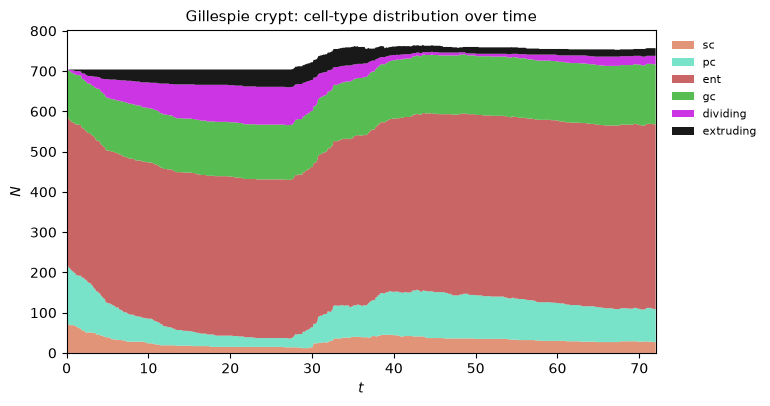

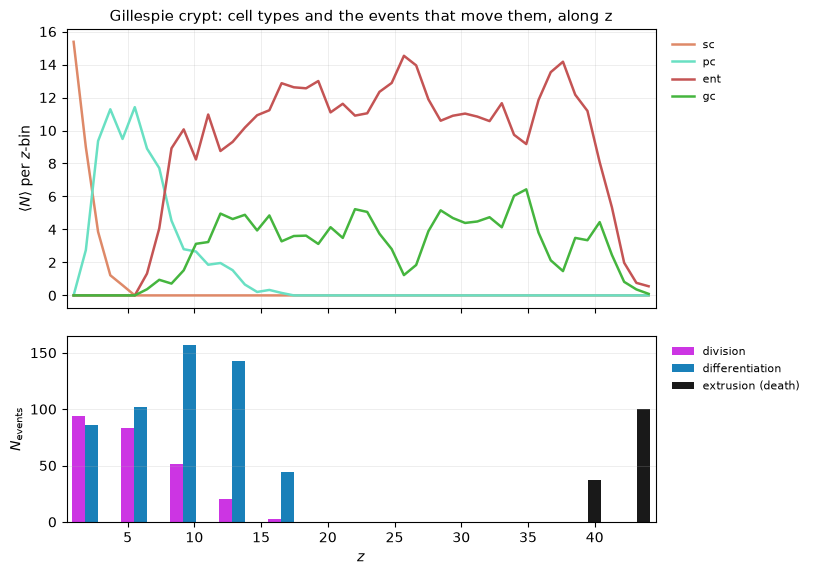

[gillespie] done


[gillespie_restart] loaded 366 events


/opt/anaconda3/envs/vivarium-tyssue/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:688: RuntimeWarning: overflow encountered in scalar subtract
  v0, v1 = inverse_trans.transform([v0t - delta, v1t + delta])
/opt/anaconda3/envs/vivarium-tyssue/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:688: RuntimeWarning: overflow encountered in scalar subtract
  v0, v1 = inverse_trans.transform([v0t - delta, v1t + delta])


/opt/anaconda3/envs/vivarium-tyssue/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:688: RuntimeWarning: overflow encountered in scalar subtract
  v0, v1 = inverse_trans.transform([v0t - delta, v1t + delta])
/opt/anaconda3/envs/vivarium-tyssue/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:866: RuntimeWarning: overflow encountered in scalar subtract
  delta = (upper_t - lower_t) * view_margin
/opt/anaconda3/envs/vivarium-tyssue/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:868: RuntimeWarning: overflow encountered in scalar subtract
  new_range = [lower_t - delta, upper_t + delta]
/opt/anaconda3/envs/vivarium-tyssue/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:688: RuntimeWarning: overflow encountered in scalar subtract
  v0, v1 = inverse_trans.transform([v0t - delta, v1t + delta])
/opt/anaconda3/envs/vivarium-tyssue/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:866: RuntimeWarning: overflow encountered in scalar subtr

frame t = 26.61 failed (ValueError: Axis limits cannot be NaN or Inf); skipping
frame t = 27.23 failed (ValueError: Axis limits cannot be NaN or Inf); skipping


...

/Users/tasnifrahman/PycharmProjects/vivatyssue/src/tyssue/draw/plt_draw.py:874: RuntimeWarning: overflow encountered in scalar multiply
  size = max(min_size, round(base_size * min(ranges) / max_range))


frame t = 61.09 failed (OverflowError: cannot convert float infinity to integer); skipping


/opt/anaconda3/envs/vivarium-tyssue/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:688: RuntimeWarning: overflow encountered in scalar subtract
  v0, v1 = inverse_trans.transform([v0t - delta, v1t + delta])
/opt/anaconda3/envs/vivarium-tyssue/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:688: RuntimeWarning: overflow encountered in scalar subtract
  v0, v1 = inverse_trans.transform([v0t - delta, v1t + delta])


/opt/anaconda3/envs/vivarium-tyssue/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:688: RuntimeWarning: overflow encountered in scalar subtract
  v0, v1 = inverse_trans.transform([v0t - delta, v1t + delta])
/opt/anaconda3/envs/vivarium-tyssue/lib/python3.12/site-packages/mpl_toolkits/mplot3d/axes3d.py:688: RuntimeWarning: overflow encountered in scalar subtract
  v0, v1 = inverse_trans.transform([v0t - delta, v1t + delta])


  wrote gillespie_restart.gif (116 frames)


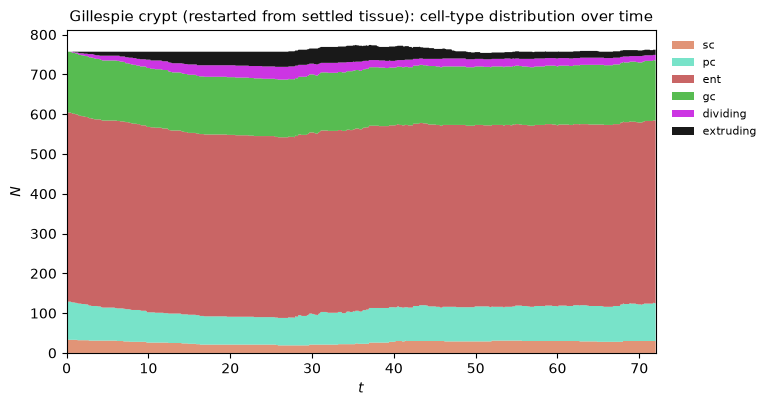

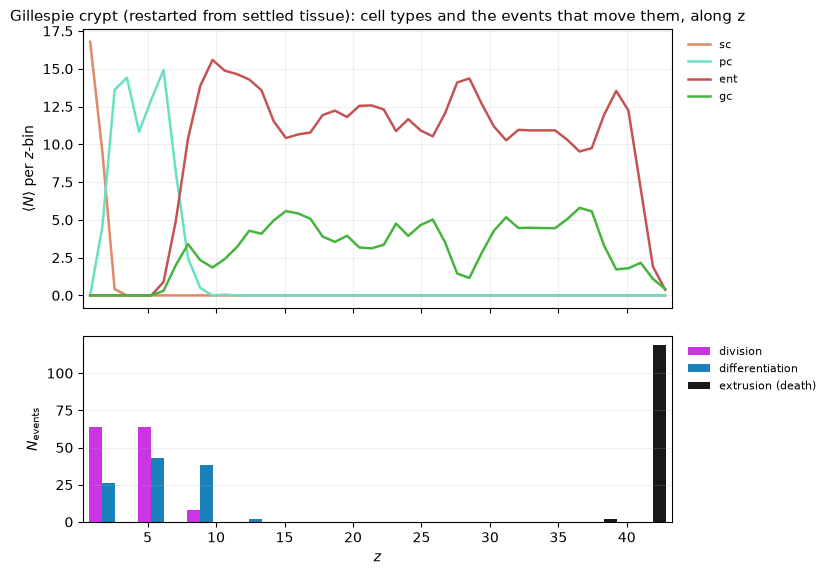

[gillespie_restart] done


In [10]:
# Same pipeline for both crypt runs — they differ only in their starting mesh,
# so the GIF, stills and both analyses are produced identically for each.
counts_by_run = {}

for run in ("gillespie", "gillespie_restart"):
    run_dir = OUT_DIR / run
    run_path = run_dir / "history.hf5"
    if not run_path.exists():
        print(f"no {run} archive — run `python discrete_events.py {run}` first")
        continue
    label = RUN_LABELS[run]
    hist = LoadedHistory(run_path)
    events = load_events(run_dir / "events.csv")
    print(f"[{run}] loaded {len(events)} events")

    if MAKE_GIFS:
        save_gif_3d(hist, run_dir / f"{run}.gif")
    save_stills_3d(hist, run_dir)

    counts = cell_type_over_time(hist)
    counts.to_csv(run_dir / "cell_type_over_time.csv", index=False)
    plot_cell_type_over_time(counts, run_dir / "cell_type_over_time.png", label)
    counts_by_run[run] = counts

    ctz = cell_type_along_z(hist)
    ctz.to_csv(run_dir / "cell_type_along_z.csv", index=False)

    evz = events_along_z(hist, events)
    evz.to_csv(run_dir / "events_along_z.csv", index=False)

    # composition and events share the crypt axis -> one figure, two panels
    plot_along_z(ctz, evz, run_dir / "along_z.png", label)
    print(f"[{run}] done")


## Fresh mesh vs. settled mesh — the two crypt runs compared

`gillespie` and `gillespie_restart` are the same model with the same parameters and
the same solver step; the only difference is where they start. The first begins on
the stock `crypt_cylinder.hf5`, whose cell types were assigned from a spatial prior
rather than produced by the dynamics, so its first ~40 time units are the tissue
relaxing *into* the crypt's stationary composition. The second begins on the mesh
the first one ends on, so that transient is already spent and the window shows the
stationary state itself.


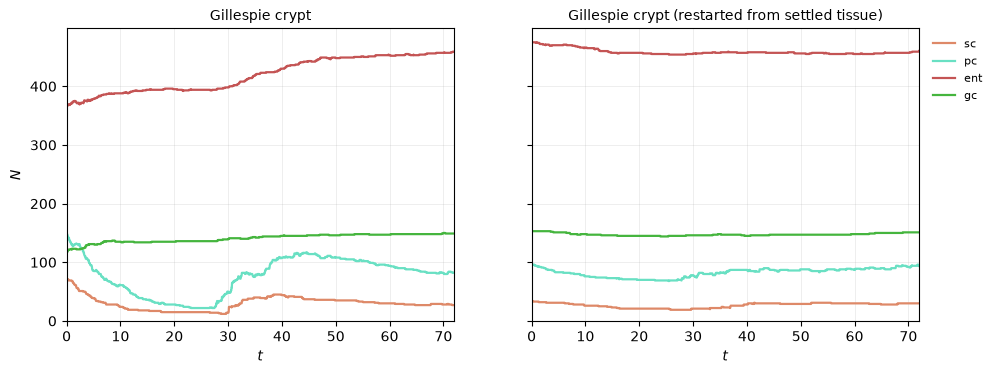

In [11]:
plot_runs_compared(counts_by_run, OUT_DIR / "gillespie_restart" / "runs_compared.png")
